In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import splitfolders

In [2]:
SOURCE_DIR = r"C:\Users\LENOVO\Desktop\IIS_Project\Foods"
OUTPUT_DIR = r"C:\Users\LENOVO\Desktop\IIS_Project\Splited_DataSet"

TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
VAL_DIR   = os.path.join(OUTPUT_DIR, "val")
TEST_DIR  = os.path.join(OUTPUT_DIR, "test")

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 12
SEED = 123

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClasses:", class_names)
print("Number of classes:", num_classes)

Found 2329 files belonging to 5 classes.
Found 498 files belonging to 5 classes.
Found 504 files belonging to 5 classes.

Classes: ['Chapathi', 'Dhal', 'Idli', 'Jelebi', 'Samosa']
Number of classes: 5


In [5]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

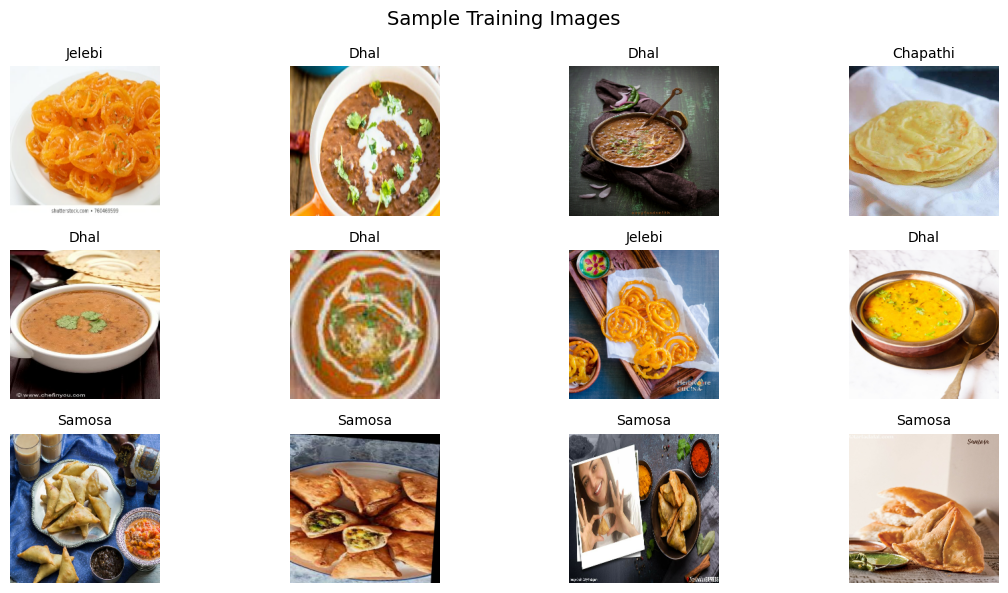

In [6]:
plt.figure(figsize=(12, 6))
images, labels = next(iter(train_ds))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])], fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


Class Distribution Table:
Class		Train	Val	Test	Total
Chapathi		546	117	118	781
Dhal		513	109	111	733
Idli		489	105	106	700
Jelebi		440	94	95	629
Samosa		341	73	74	488


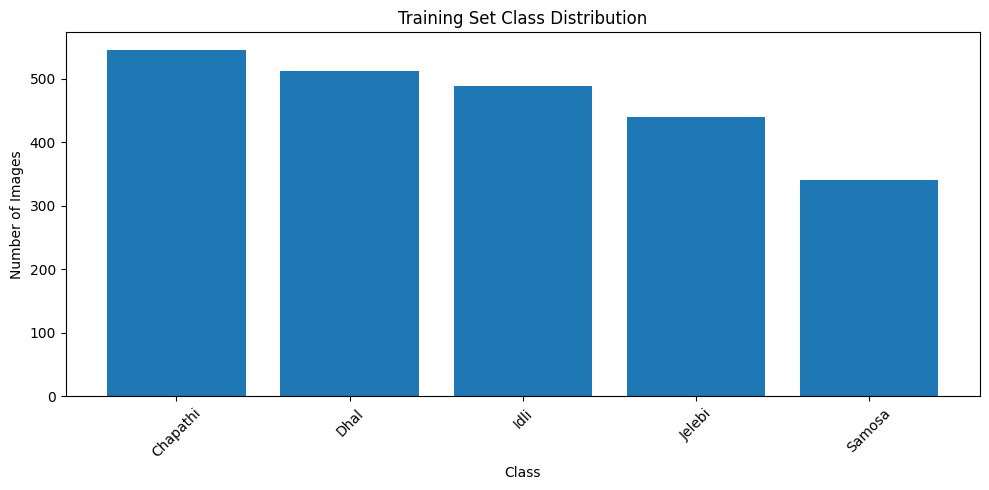

In [7]:
def count_images(folder, class_names):
    counts = []
    for cls in class_names:
        cls_path = os.path.join(folder, cls)
        count = 0
        if os.path.exists(cls_path):
            for f in os.listdir(cls_path):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    count += 1
        counts.append(count)
    return counts

train_counts = count_images(TRAIN_DIR, class_names)
val_counts = count_images(VAL_DIR, class_names)
test_counts = count_images(TEST_DIR, class_names)

print("\nClass Distribution Table:")
print("Class\t\tTrain\tVal\tTest\tTotal")
for i, cls in enumerate(class_names):
    total = train_counts[i] + val_counts[i] + test_counts[i]
    print(f"{cls}\t\t{train_counts[i]}\t{val_counts[i]}\t{test_counts[i]}\t{total}")

plt.figure(figsize=(10, 5))
plt.bar(class_names, train_counts)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
train_labels_for_weights = []
for _, y in train_ds.unbatch():
    train_labels_for_weights.append(int(y.numpy()))

train_labels_for_weights = np.array(train_labels_for_weights)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels_for_weights
)

class_weights = {i: class_weights_array[i] for i in range(num_classes)}

print("\nClass Weights:")
for i, w in class_weights.items():
    print(f"{class_names[i]}: {w:.4f}")


Class Weights:
Chapathi: 0.8531
Dhal: 0.9080
Idli: 0.9526
Jelebi: 1.0586
Samosa: 1.3660


In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08)
], name="data_augmentation")

In [10]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="Food_Image_Classifier")

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "Food_Image_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 2,026,053 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.7213 - loss: 0.7602 - val_accuracy: 0.8494 - val_loss: 0.4304 - learning_rate: 1.0000e-04
Epoch 2/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9386 - loss: 0.1872 - val_accuracy: 0.8735 - val_loss: 0.3277 - learning_rate: 1.0000e-04
Epoch 3/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9626 - loss: 0.1042 - val_accuracy: 0.9257 - val_loss: 0.1887 - learning_rate: 1.0000e-04
Epoch 4/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9734 - loss: 0.0856 - val_accuracy: 0.9518 - val_loss: 0.1200 - learning_rate: 1.0000e-04
Epoch 5/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9820 - loss: 0.0694 - val_accuracy: 0.9538 - val_loss: 0.1098 - learning_rate: 1.0000e-04
Epoch 6/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9901 - loss: 0.0372 - val_accuracy: 0.9618 - val_loss: 0.0962 - learning_rate: 1.0000e-04
Epoch 7/12
73/73 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9867 - los

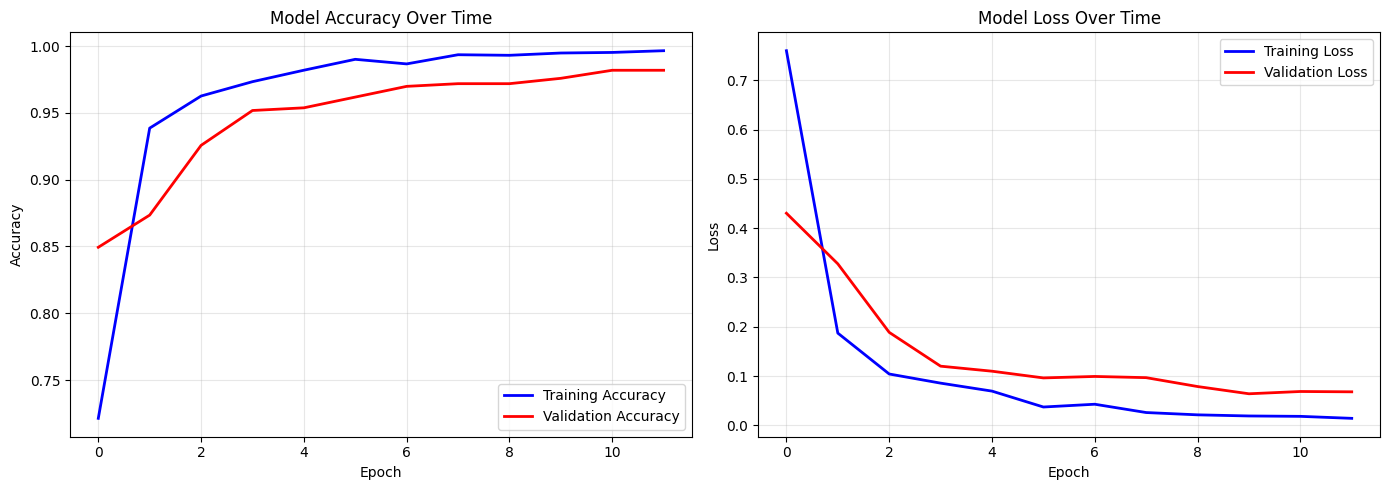

In [22]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy", color="blue", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="red", linewidth=2)
plt.title("Model Accuracy Over Time")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss", color="blue", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", color="red", linewidth=2)
plt.title("Model Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 98.21%
Test Loss: 0.0571


In [17]:
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

In [18]:
print("\nClassification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


Classification Report:
              precision    recall  f1-score   support

    Chapathi      0.975     1.000     0.987       118
        Dhal      1.000     0.982     0.991       111
        Idli      1.000     0.972     0.986       106
      Jelebi      0.949     0.989     0.969        95
      Samosa      0.986     0.959     0.973        74

    accuracy                          0.982       504
   macro avg      0.982     0.981     0.981       504
weighted avg      0.983     0.982     0.982       504



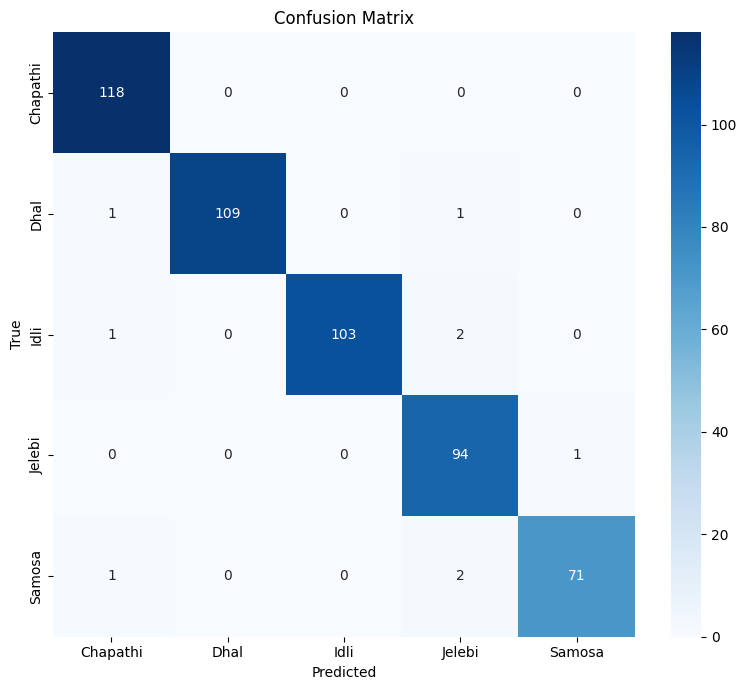

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

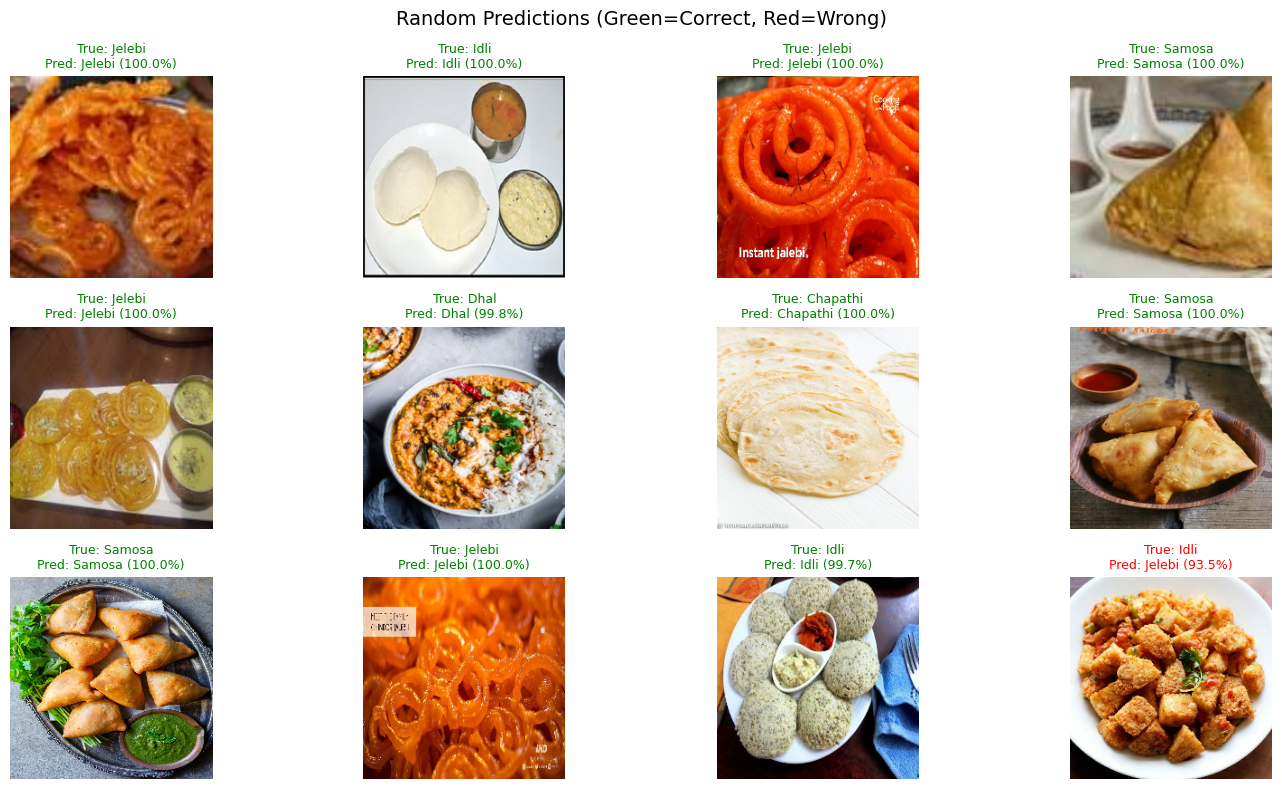

In [21]:
all_test_images = []
all_test_labels = []

for imgs, labs in test_ds:
    all_test_images.append(imgs.numpy())
    all_test_labels.append(labs.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels = np.concatenate(all_test_labels, axis=0)

plt.figure(figsize=(15, 8))
num_images = 12
random_indices = np.random.choice(len(all_test_images), num_images, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 4, i + 1)

    img = all_test_images[idx]
    true_idx = int(all_test_labels[idx])

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_idx = int(np.argmax(pred))
    conf = pred[pred_idx] * 100

    color = "green" if pred_idx == true_idx else "red"

    plt.imshow(img.astype("uint8"))
    plt.title(
        f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]} ({conf:.1f}%)",
        fontsize=9,
        color=color
    )
    plt.axis("off")

plt.suptitle("Random Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
save_path = os.path.join(os.getcwd(), "model_v2.h5")

model.save(save_path)

print("\nModel successfully saved!")
print("Save location:", save_path)


Model successfully saved!
Save location: C:\Users\LENOVO\Desktop\IIS_Project\model_v2.h5


Observations:-

The improved model achieved 98.21% test accuracy, which is much higher than the baseline model accuracy of 81.75%.

Training and validation curves show stable learning with much less overfitting.

MobileNetV2 transfer learning significantly improved feature extraction and classification performance.

Data augmentation and dropout helped the model generalize better to unseen images.

The confusion matrix confirmed that most images were classified correctly, with very few misclassifications.

Weak classes from Implementation 1, especially Samosa, showed clear improvement in Implementation 2.

The final model performed very well, but it is still limited to the five classes used in the dataset.